### MODEL TRAINING


In [1]:
import pandas as pd
import numpy as np
import joblib

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [3]:
from sklearn.ensemble import (
  RandomForestClassifier,
  GradientBoostingClassifier,
  ExtraTreesClassifier
)

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")

In [8]:
df=pd.read_csv(r'C:\Users\Rashu\Downloads\AIML Projects\Industrial Predictive Maintenance System\data\cleaned_data.csv')
df.head()

,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
X=df.drop("Machine_failure",axis=1)
y=df["Machine_failure"]

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [12]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [13]:
models={
  "Logistic Regression":LogisticRegression(),
  "Decision Tree":DecisionTreeClassifier(random_state=42),
  "Random Forest":RandomForestClassifier(random_state=42),
  "Gradient Boosting":GradientBoostingClassifier(random_state=42),
  "Extra Trees":ExtraTreesClassifier(random_state=42)}

In [14]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    roc = roc_auc_score(y_test, prediction)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc
    })

In [15]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.999,
  'Precision': 1.0,
  'Recall': 0.9705882352941176,
  'F1 Score': 0.9850746268656716,
  'ROC AUC': 0.9852941176470589},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9985,
  'Precision': 0.9850746268656716,
  'Recall': 0.9705882352941176,
  'F1 Score': 0.9777777777777777,
  'ROC AUC': 0.9850353184752163},
 {'Model': 'Random Forest',
  'Accuracy': 0.999,
  'Precision': 1.0,
  'Recall': 0.9705882352941176,
  'F1 Score': 0.9850746268656716,
  'ROC AUC': 0.9852941176470589},
 {'Model': 'Gradient Boosting',
  'Accuracy': 0.999,
  'Precision': 1.0,
  'Recall': 0.9705882352941176,
  'F1 Score': 0.9850746268656716,
  'ROC AUC': 0.9852941176470589},
 {'Model': 'Extra Trees',
  'Accuracy': 0.999,
  'Precision': 1.0,
  'Recall': 0.9705882352941176,
  'F1 Score': 0.9850746268656716,
  'ROC AUC': 0.9852941176470589}]

In [16]:
results_df=pd.DataFrame(results)

results_df.sort_values(
 by="F1 Score",ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9990,1.000000,0.970588,0.985075,0.985294
2,Random Forest,0.9990,1.000000,0.970588,0.985075,0.985294
3,Gradient Boosting,0.9990,1.000000,0.970588,0.985075,0.985294
4,Extra Trees,0.9990,1.000000,0.970588,0.985075,0.985294
1,Decision Tree,0.9985,0.985075,0.970588,0.977778,0.985035


In [17]:
best_model=RandomForestClassifier(
  random_state=42
)
best_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [18]:
joblib.dump(
    best_model,
    "../artifacts/model.pkl"
)

['../artifacts/model.pkl']

In [19]:
joblib.dump(
    scaler,
    "../artifacts/scaler.pkl"
)

['../artifacts/scaler.pkl']

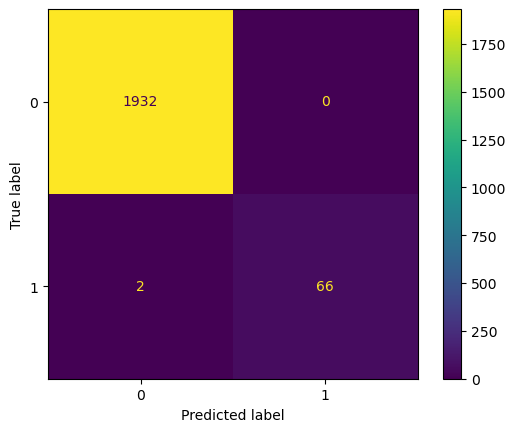

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
  best_model,X_test,y_test
)

In [21]:
prediction=best_model.predict(X_test)
print(
  classification_report(y_test,prediction)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [22]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
7,HDF,0.272093
9,OSF,0.232373
8,PWF,0.200104
6,TWF,0.108812
4,Torque_Nm,0.076630
3,Rotational_speed_rpm,0.044600
5,Tool_wear_min,0.028837
1,Air_temperature_K,0.017290
2,Process_temperature_K,0.015728
0,Type,0.003187


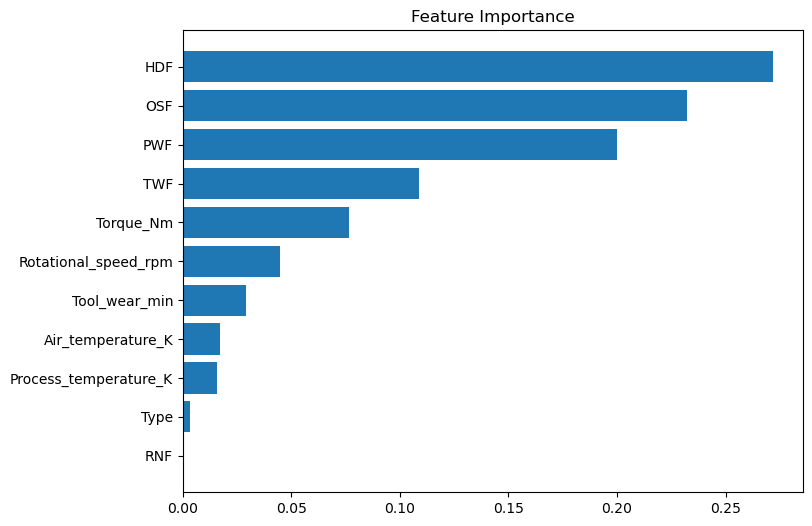

In [23]:
import matplotlib.pyplot as plt
importance=importance.sort_values('Importance')
plt.figure(figsize=(8,6))
plt.barh(
  importance["Feature"],
  importance["Importance"]
)
plt.title("Feature Importance")
plt.show()